<!-- ## init -->

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set all fonts to Arial size 7
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7
})

In [3]:
from autoadsorbate import Surface
from ase.io import read, write
from ase.visualize import view
import numpy as np
from ase import Atoms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.ticker import FixedLocator


from cft import Manifold
from autoadsorbate.Particle import get_cube_surface_pts, grid_round_cube
from cft.mesh_utils import compute_outward_vertex_normals_quads

from ase.io import read, write
from ase.visualize import view
from autoadsorbate import Fragment
from autoadsorbate.Surf import attach_fragment
from ase.constraints import FixAtoms
import copy

In [4]:
from mace.calculators import mace_mp
clean_calc = mace_mp(model=
                # '/mnt/c/Users/ef/Desktop/tmp/mace-mh-nl-pbe.model',
                '/mnt/c/Users/ef/Desktop/tmp/mace-omat-0-medium.model',
                device='cpu',
                )

/home/ef/venvs/mace_env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/ef/venvs/mace_env/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head default out of ['default']
Default dtype float32 does not match model dtype float64, converting models to float32.


<!-- ## make data for Kjell -->

In [5]:
rh_trj = read('/home/ef/Code/bo-adsorbate/examples/run_particle/rh_28.xyz', index=':')
len(rh_trj)

34

In [6]:
# for atoms in rh_trj:
#     print(atoms.get_chemical_formula())

In [7]:
# relaxed_trj = read('/home/ef/kuma_scratch/rh28_lignads/relaxed_out.xyz', index=':')

relaxed_trj = read('/home/ef/Code/CFT/examples/rh28_lignads/relaxed_out.xyz', index=':')

len(relaxed_trj)

800

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dscribe.descriptors import SOAP
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


def gather_species(atoms_list):
    species = set()
    for at in atoms_list:
        species.update(at.get_chemical_symbols())
    return sorted(list(species))


def compute_rh_centered_soap(atoms_list, soap_params, species):
    soap = SOAP(species=species, **soap_params)
    soap_vectors = []
    rh_counts = []
    for at in atoms_list:
        symbols = at.get_chemical_symbols()
        rh_indices = [i for i, s in enumerate(symbols) if s == "Rh"]
        if len(rh_indices) == 0:
            soap_vectors.append(np.full(soap.get_number_of_features(), np.nan))
            rh_counts.append(0)
            continue
        desc = soap.create(at, centers=rh_indices)  # centers = indices
        avg = np.mean(desc, axis=0)
        soap_vectors.append(avg)
        rh_counts.append(len(rh_indices))
    return np.vstack(soap_vectors), np.array(rh_counts)


def make_rh_soap_tsne_df(atoms_list):
    species = gather_species(atoms_list)
    print("Species for SOAP:", species)

    soap_vecs, rh_counts = compute_rh_centered_soap(atoms_list, soap_params, species)
    mask = ~np.isnan(soap_vecs).any(axis=1)
    soap_valid = soap_vecs[mask]
    atoms_valid = [at for i, at in enumerate(atoms_list) if mask[i]]

    # scale and embed
    soap_scaled = StandardScaler().fit_transform(soap_valid)
    tsne = TSNE(**TSNE_PARAMS)
    coords = tsne.fit_transform(soap_scaled)

    # potential energies
    energies = [at.get_potential_energy() for at in atoms_valid]
    e_per_ligand = [
        (at.get_potential_energy() - at.info['static_energy'])/at.info['n_fragments'] for at in atoms_valid
        ]
    n_fragments = [at.info['n_fragments'] for at in atoms_valid]

    df = pd.DataFrame({
        "tsne_x": coords[:, 0],
        "tsne_y": coords[:, 1],
        "energy": energies,
        'relative energy': e_per_ligand,
        'n_fragments': n_fragments
    })

    return df, soap_vecs


def plot_tsne_energy(df):
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(df.tsne_x, df.tsne_y, c=df['relative energy'], cmap="plasma", s=40)
    plt.colorbar(sc, label="Relative energy (eV)")
    # plt.title("t-SNE of Rh-centered SOAP vectors (colored by energy)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()


import numpy as np
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
import random


def plot_tsne_with_structures(df, atoms_list, n_rows=3, n_cols_each_side=3, fig_size=(14, 8)):
    """
    df: DataFrame with 'tsne_x', 'tsne_y', 'energy'
    atoms_list: full dataset (ASE Atoms objects), in the same order used to build df
    """

    n_total = n_rows * n_cols_each_side * 2  # left + right
    chosen_idx = random.sample(list(df.index), min(n_total, len(df)))

    left_idx = chosen_idx[: n_rows * n_cols_each_side]
    right_idx = chosen_idx[n_rows * n_cols_each_side :]

    # fixed drawing parameters for consistent scale
    common_kw = {"radii": 1.3, "rotation": ("45x,45y,0z"), "show_unit_cell": 0}

    # figure grid
    fig = plt.figure(figsize=fig_size, dpi=600)
    gs = fig.add_gridspec(n_rows, 2 * n_cols_each_side + 1, wspace=0.05, hspace=0.05)

    # left structures
    for i in range(n_rows):
        for j in range(n_cols_each_side):
            idx = i * n_cols_each_side + j
            if idx >= len(left_idx): continue
            at_idx = left_idx[idx]
            ax = fig.add_subplot(gs[i, j])
            plot_atoms(atoms_list[at_idx], ax, **common_kw)
            ax.axis("off")

    # center TSNE
    ax_center = fig.add_subplot(gs[:, n_cols_each_side : -n_cols_each_side])
    sc = ax_center.scatter(df.tsne_x, df.tsne_y, c=df['n_fragments'], cmap="plasma", s=40, alpha=0.8)
    # highlight shown structures
    highlight_idx = left_idx + right_idx
    ax_center.scatter(df.tsne_x.iloc[highlight_idx],
                      df.tsne_y.iloc[highlight_idx],
                      facecolors='none', edgecolors='black', s=120, linewidths=1.5, label="Shown structures")
    ax_center.set_xlabel("t-SNE 1")
    ax_center.set_ylabel("t-SNE 2")
    ax_center.set_title("t-SNE embedding")
    plt.colorbar(sc, ax=ax_center, fraction=0.046, pad=0.04, label="Energy (eV)")
    ax_center.legend(loc="best")

    # right structures
    for i in range(n_rows):
        for j in range(n_cols_each_side):
            idx = i * n_cols_each_side + j
            if idx >= len(right_idx): continue
            at_idx = right_idx[idx]
            ax = fig.add_subplot(gs[i, -(n_cols_each_side) + j])
            plot_atoms(atoms_list[at_idx], ax, **common_kw)
            ax.axis("off")

    plt.show()


In [9]:
# view(relaxed_trj)

In [ ]:
# === Parameters ===
soap_params = {
    "r_cut": 5.0,
    "n_max": 8,
    "l_max": 6,
    "sigma": 0.5,
    "periodic": False,
    "sparse": False,
}
TSNE_PARAMS = {"n_components": 2, "perplexity": 4, "learning_rate": 200, "random_state": 42}


# df, soap_vectors = rh_soap_tsne(relaxed_trj)
df, soap_vectors = make_rh_soap_tsne_df(relaxed_trj)

Species for SOAP: ['C', 'H', 'P', 'Rh']


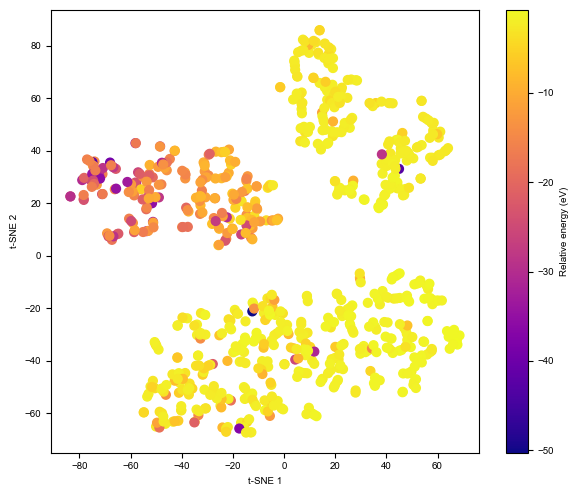

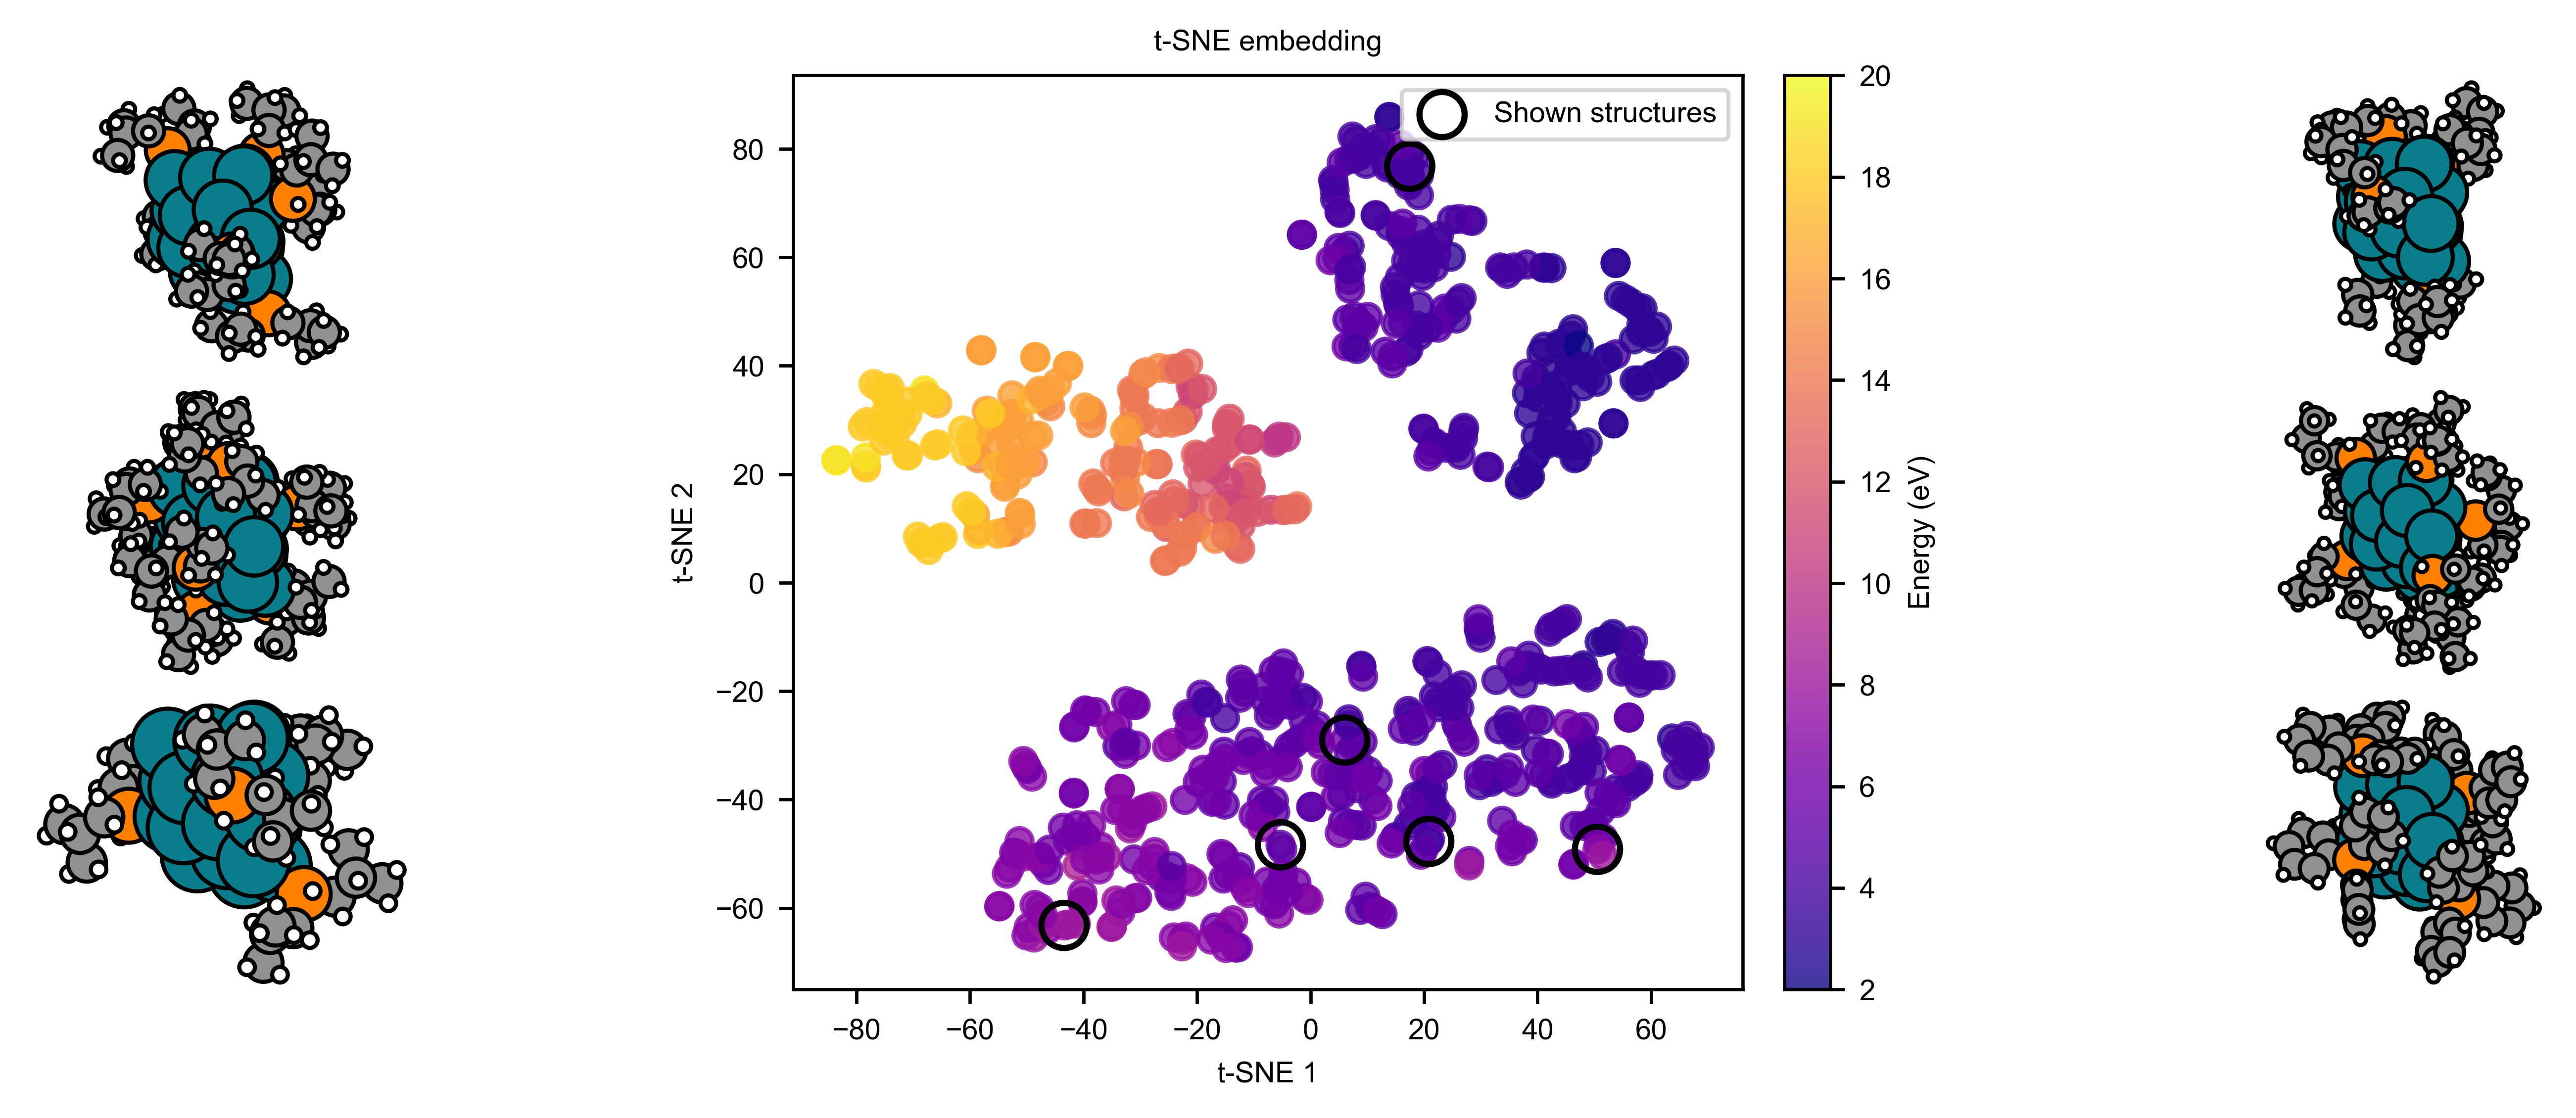

In [27]:
plot_tsne_energy(df)
plot_tsne_with_structures(df, relaxed_trj, n_rows=3, n_cols_each_side=1, fig_size=(14, 4))

<!-- ## manifold -->

In [ ]:
from cft import Manifold
m = Manifold(rh_trj[0], mode='particle', precision=2.)

<!-- ## ligands -->

In [ ]:
from rdkit import Chem

def reorder_smiles_by_atom(smiles: str, atom_index: int) -> str:
    """
    Reformat a SMILES string so that the atom at `atom_index` appears first.

    Args:
        smiles (str): Input SMILES string.
        atom_index (int): Index of the atom to appear first (0-based).

    Returns:
        str: Reordered canonical SMILES with the specified atom first.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES string")

    n_atoms = mol.GetNumAtoms()

    print(f'{n_atoms = }')

    if atom_index < 0 or atom_index >= n_atoms:
        raise IndexError("atom_index out of range")

    # Create new atom ordering: specified atom first, then the rest
    new_order = [atom_index] + [i for i in range(n_atoms) if i != atom_index]

    # Renumber atoms
    mol_reordered = Chem.RenumberAtoms(mol, new_order)

    # Generate canonical SMILES
    smiles_reordered = Chem.MolToSmiles(mol_reordered, canonical=False)
    return smiles_reordered


from rdkit import Chem

def find_atom_indices(smiles: str, element: str):
    """
    Return a list of atom indices in the molecule with the specified element.

    Args:
        smiles (str): Input SMILES string.
        element (str): Atomic symbol to search for (e.g., "O", "N", "P").

    Returns:
        List[int]: List of atom indices matching the element.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES string")

    indices = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetSymbol() == element]
    return indices


In [13]:
from rdkit import Chem

EXTRA_BOND_MAP = {
    "N": "[N+]",
    "P": "[P+]",
    "O": "[O-]",
    "S": "[S+]",
    "Cl": "[Cl+]",
    "Br": "[Br+]",
}

def add_formal_charge_hardcoded(smiles: str, atom_index: int) -> str:
    """
    Given a SMILES and an atom index:
      - Replaces that atom with its charged version from EXTRA_BOND_MAP.
      - Preserves the original SMILES order and structure.
      - Adds explicit hydrogens only if the indexed atom has them.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")

    # Get target atom
    atom = mol.GetAtomWithIdx(atom_index)
    symbol = atom.GetSymbol()
    if symbol not in EXTRA_BOND_MAP:
        return smiles

    # Tag the atom so we can locate it in the output SMILES
    atom.SetAtomMapNum(999)

    # Generate a non-canonical SMILES (keeps original ordering)
    smi = Chem.MolToSmiles(mol, canonical=False)

    # Replace the tagged atom only
    target1 = f"[{symbol}:999]"
    target2 = f"{symbol}:999"
    if target1 in smi:
        smi = smi.replace(target1, EXTRA_BOND_MAP[symbol])
    elif target2 in smi:
        smi = smi.replace(target2, EXTRA_BOND_MAP[symbol])

    # Remove any leftover map number markers
    smi = smi.replace(":999", "")

    return smi


In [5]:
dfl = pd.read_csv('/home/ef/Code/CFT/examples/swiss_ai/phosphine_ligands_enriched.csv', delimiter=',')

In [90]:
dfl

,Name,Category,SMILES,CAS,PubChem_CID,surrogateSMILES
0,Triphenylphosphine,Triarylphosphine,c1ccccc1P(c2ccccc2)c3ccccc3,603-35-0,11776.0,Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3
1,Tri(o-tolyl)phosphine,Triarylphosphine,Cc1ccccc1P(c2ccccc2C)c3ccccc3C,6163-58-2,287822.0,Cl[P+](c1ccccc1C)(c2ccccc2C)c3ccccc3C
2,Tri(2-furyl)phosphine,Triarylphosphine,c1coc(c1)P(c2ccco2)c3ccco3,838-03-3,383767.0,Cl[P+](c1cocc1)(c2ccco2)c3ccco3
3,Triisopropylphosphine,Alkylphosphine,CC(C)P(C(C)C)C(C)C,15428-64-5,6309.0,Cl[P+](C(C)C)(C(C)C)C(C)C
4,Triethylphosphine,Alkylphosphine,CCP(CC)P(C)C,1493-86-5,6296.0,Cl[P+](CC)(CC)CC
5,Trimethylphosphine,Alkylphosphine,P(C)C,124-40-3,6260.0,Cl[P+](C)(C)C
6,Tri-n-butylphosphine,Alkylphosphine,CCCCP(CCCC)CCCC,998-40-5,10424.0,Cl[P+](CCCC)(CCCC)CCCC
7,Tricyclohexylphosphine,Alkylphosphine,C1CCC(CC1)P(C2CCCCC2)C3CCCCC3,1026-26-6,75806.0,Cl[P+](C1CCCCC1)(C2CCCCC2)C3CCCCC3
8,Tri(4-methoxyphenyl)phosphine,Triarylphosphine,COc1ccc(cc1)P(c2ccc(OC)cc2)c3ccc(OC)cc3,16616-01-4,108441.0,Cl[P+](c1ccc(OC)cc1)(c2ccc(OC)cc2)c3ccc(OC)cc3
9,Tri(4-fluorophenyl)phosphine,Triarylphosphine,Fc1ccc(cc1)P(c2ccc(F)cc2)c3ccc(F)cc3,994-02-7,69159.0,Cl[P+](c1ccc(F)cc1)(c2ccc(F)cc2)c3ccc(F)cc3


In [89]:
view_trj = []
for i, smile in enumerate(dfl.surrogateSMILES.values):
    print(f'{smile = }')
    view_trj+=Fragment(smile, to_initialize=1).conformers
    

view(view_trj)

smile = 'Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](c1ccccc1C)(c2ccccc2C)c3ccccc3C'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](c1cocc1)(c2ccco2)c3ccco3'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](C(C)C)(C(C)C)C(C)C'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](CC)(CC)CC'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](C)(C)C'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](CCCC)(CCCC)CCCC'


[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:17] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom:

User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](C1CCCCC1)(C2CCCCC2)C3CCCCC3'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](c1ccc(OC)cc1)(c2ccc(OC)cc2)c3ccc(OC)cc3'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](c1ccc(F)cc1)(c2ccc(F)cc2)c3ccc(F)cc3'


[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 2
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 2
[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1


User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](c1cc(C)cc(C)c1)(c1cc(C)cc(C)c1)(c1cc(C)cc(C)c1)'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[O+][P+](c1ccccc1)(c2ccccc2)c3ccccc3'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = 'Cl[P+](c1cc(C(C)C)cc(C(C)C)c1)(c1cc(C(C)C)cc(C(C)C)c1)(c1cc(C(C)C)cc(C(C)C)c1)'


[06:18:18] UFFTYPER: Unrecognized charge state for atom: 1


User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
smile = nan


TypeError: No registered converter was able to produce a C++ rvalue of type std::__cxx11::basic_string<wchar_t, std::char_traits<wchar_t>, std::allocator<wchar_t> > from this Python object of type float

In [ ]:
view_trj = []
for i, smile in enumerate([
    'Cl[P+](c1c(c2c(OC(C)C)cccc2(OC(C)C))cccc1)(c3cc(C(F)(F)F)cc(C(F)(F)F)c3)c3cc(C(F)(F)F)cc(C(F)(F)F)c3'
]):
    if pd.isna(smile):
        print(smile)
        continue
    print(f'{smile = }')
    view_trj+=Fragment(smile, to_initialize=1).conformers
    

view(view_trj)

smile = 'Cl[P+](c1c(c2c(OC(C)C)cccc2(OC(C)C))cccc1)(c3cc(C(F)(F)F)cc(C(F)(F)F)c3)c3cc(C(F)(F)F)cc(C(F)(F)F)c3'
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.


[14:28:35] UFFTYPER: Unrecognized charge state for atom: 1
[14:28:35] UFFTYPER: Unrecognized charge state for atom: 1


<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [10]:
import ijson

In [12]:
with open("data_json/data.json", "r") as file:
    for item in ijson.items(file, "item"):
        # 'item' iterates through elements of the top-level array
        print(item["name"])

IncompleteJSONError: lexical error: invalid char in json text.
          : 110, "similar_structures": NaN, "references": "http://muel
                     (right here) ------^


In [16]:
import pandas as pd

df = pd.read_json("data_json/data.json", lines=False)
df = df.T

In [17]:
df.columns

Index(['cluster_id', 'energy_n_minus_one', 'energy_n_plus_one',
       'homo_lumo_gap', 'n_val_electrons', 'similar_structures', 'references',
       'magnetic_moment', 'element_symbol', 'n_atoms', 'energy_dft',
       'energy_relative', 'structure_xyz', 'structure_poscar_format'],
      dtype='object')

In [18]:
df

,cluster_id,energy_n_minus_one,energy_n_plus_one,homo_lumo_gap,n_val_electrons,similar_structures,references,magnetic_moment,element_symbol,n_atoms,energy_dft,energy_relative,structure_xyz,structure_poscar_format
0,Ag/10/1,-2.07576,1.71752,0.94520,110,Cu/10/1 Cs/10/23 Ru/10/37 Mg/10/18 Co/10/3 Os/...,https://doi.org/10.1039/C7CP02240A,0.00000,Ag,10,-17.964702,0.0,10;Energy = -17.96470240 eV;Ag 13.346948648507...,Unknown Structure <s> Ag </s>;1.00000000000000...
1,Ag/10/10,-1.84480,1.94848,0.84070,110,Cu/10/8 Au/10/6 Pt/10/24,http://muellergroup.jhu.edu/,0.00000,Ag,10,-17.73374,0.230962,10;Energy = -17.73374002 eV;Ag 15.883926705967...,Unknown Structure <s> Ag </s>;1.00000000000000...
2,Ag/10/11,-1.84193,1.95135,0.93980,110,None,http://muellergroup.jhu.edu/,0.00000,Ag,10,-17.730873,0.23383,10;Energy = -17.73087262 eV;Ag 6.4572862033834...,Al10 -26.42114976 <s> Ag </s>;1.0000000000000...
3,Ag/10/12,-1.83865,1.95463,0.82450,110,Cu/10/12 Na/10/32 Cs/10/15 Au/10/10 Rb/10/19,http://muellergroup.jhu.edu/,-0.00010,Ag,10,-17.727589,0.237113,10;Energy = -17.72758926 eV;Ag 9.9482218473297...,Ag10 -17.73927061 <s> Ag </s>;1.000000000000...
4,Ag/10/13,-1.83310,1.96018,1.02010,110,Rb/10/9 Al/10/16 K/10/21 Be/10/16 Li/10/23 Pt/...,http://muellergroup.jhu.edu/,0.00000,Ag,10,-17.722044,0.242658,10;Energy = -17.72204403 eV;Ag 16.081709530853...,Unknown Structure <s> Ag </s>;1.00000000000000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61684,Zr/9/5,-4.50130,5.60911,0.37170,108,Ti/9/5 Hf/9/3 Cu/9/2 Be/9/4 Ni/9/5 Rh/9/16 Pt/...,http://muellergroup.jhu.edu/,0.00000,Zr,9,-57.821727,0.710503,9;Energy = -57.82172742 eV;Zr 16.8724690969598...,Unknown Structure <s> Zr </s>;1.00000000000000...
61685,Zr/9/6,-4.32072,5.78970,0.30080,108,None,http://muellergroup.jhu.edu/,2.00010,Zr,9,-57.64114,0.89109,9;Energy = -57.64114045 eV;Zr 10.6863611539526...,Ti9 -49.49120126 <s> Zr </s>;1.00000000000000...
61686,Zr/9/7,-4.30924,5.80118,0.23410,108,B/9/15,http://muellergroup.jhu.edu/,2.00010,Zr,9,-57.629662,0.902568,9;Energy = -57.62966242 eV;Zr 18.3240845554722...,Unknown Structure <s> Zr </s>;1.00000000000000...
61687,Zr/9/8,-4.30886,5.80155,0.42960,108,None,http://muellergroup.jhu.edu/,-0.00000,Zr,9,-57.629285,0.902945,9;Energy = -57.62928548 eV;Zr 6.74493341400587...,Be9 -15.13487179 <s> Zr </s>;1.00000000000000...


/tmp/ipykernel_1035419/2247015978.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xdf["n_atoms"] = xdf["n_atoms"].astype(float)


1347


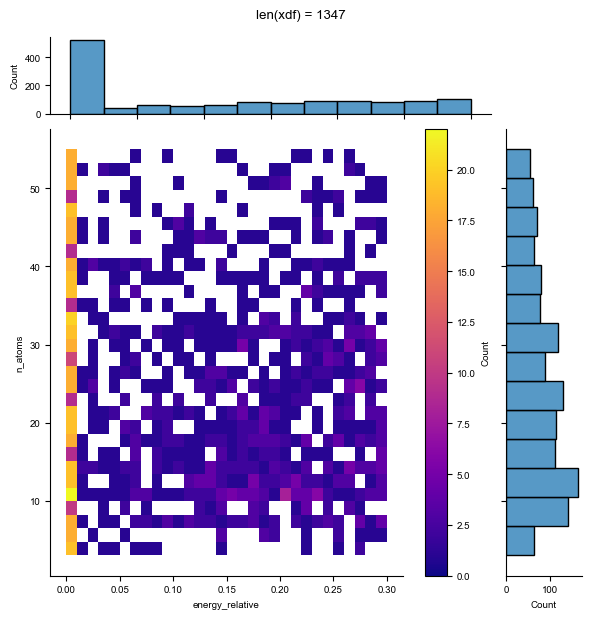

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter and prepare data
# xdf = df[(df['energy_relative'] < 0.1) & (df.element_symbol == 'Ag')].copy()
metals = ['Au','Ag','Co','Pt','Pd','Rh','Cu','Ir','Ru']
xdf = df[(df['energy_relative'] < 0.3) & df.element_symbol.isin(metals)]
xdf["n_atoms"] = xdf["n_atoms"].astype(float)
print(len(xdf))

# Create jointplot with 2D histogram and marginals
g = sns.jointplot(
    data=xdf,
    x="energy_relative",
    y="n_atoms",
    kind="hist",       # 2D histogram
    bins=30,
    cmap="plasma",
    cbar=True,         # ✅ Add colorbar
    cbar_kws={"label": "Count"},
    marginal_ticks=True
)

# Add title
g.fig.suptitle(f"{len(xdf) = }", y=1.02)

plt.show()

In [77]:
df.columns

Index(['cluster_id', 'energy_n_minus_one', 'energy_n_plus_one',
       'homo_lumo_gap', 'n_val_electrons', 'similar_structures', 'references',
       'magnetic_moment', 'element_symbol', 'n_atoms', 'energy_dft',
       'energy_relative', 'structure_xyz', 'structure_poscar_format'],
      dtype='object')

In [ ]:
def atoms_from_string(raw_text: str) -> Atoms:
    """
    Creates an ASE Atoms object from a single-line, semicolon-delimited string.
    """
    symbols = []
    positions = []

    for part in raw_text.split(';'):
        words = part.strip().split()
        
        if len(words) == 4:
            try:
                pos = [float(c) for c in words[1:]]
                symbols.append(words[0])
                positions.append(pos)
            except ValueError:
                pass
                
    return Atoms(symbols=symbols, positions=positions)

In [95]:
from ase import Atoms
from ase.db import connect
from ase.io import read
import pandas as pd
import tempfile

meta_columns = [c for c in xdf.columns if c != 'structure_poscar_format']
# db = connect("clusters.db")  # will create or overwrite existing db

cluster_trj = []

for idx, row in xdf.iterrows():
    xyz_lines = row['structure_xyz']
    atoms = atoms_from_string(xyz_lines)
    metadata = {col: row[col] for col in meta_columns}

    # db.write(atoms, **metadata)
    cluster_trj.append(atoms)
    

In [96]:
view(cluster_trj)

<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [ ]:
m = Manifold(
    atoms,
    mode='particle',
    precision=1.,
    wrap_on='sites',
    calc=clean_calc
    )


In [85]:
view(m.grid_atoms)

<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [55]:
len(dfl)

25

In [184]:
from cft.core import db_to_traj

In [247]:
view_trj = db_to_traj('db_out.db') #+ 
# view_trj = db_to_traj('db_relaxed.db')

Reading from ASE database: db_out.db
Successfully reconstructed 102 structures from the database.


In [248]:
for a in view_trj:
    print(a.info)

{'e_naked_cluster': -188332.4375, 'fragment_smiles': ['Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3', 'Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3', 'Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3', 'Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'Cl[P]', 'C

In [249]:
view_trj[-1].arrays.keys()

dict_keys(['numbers', 'positions', 'area', 'e_Cl[P]'])

In [250]:
view(view_trj)

<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

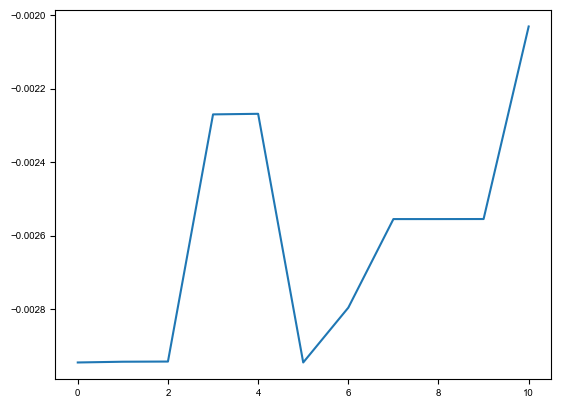

In [125]:
plt.plot([a.info['static_reward'] for a in view_trj])

In [ ]:
for a in view_trj:
    print(a.info)

{'e_naked_cluster': -202.21595764160156, 'fragment_smiles': ['Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3', 'Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3'], 'n_fragments': 2, 'static_energy': -678.99365234375, 'static_reward': -0.002945535636594541, 'stage': 'raw'}
{'e_naked_cluster': -202.21595764160156, 'fragment_smiles': ['Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3', 'Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3'], 'n_fragments': 2, 'static_energy': -679.4680786132812, 'static_reward': -0.002943478969728464, 'stage': 'raw'}
{'e_naked_cluster': -202.21595764160156, 'fragment_smiles': ['Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3', 'Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3'], 'n_fragments': 2, 'static_energy': -679.5753173828125, 'static_reward': -0.0029430144810179697, 'stage': 'raw'}
{'e_naked_cluster': -202.21595764160156, 'fragment_smiles': ['Cl[P+](c1ccccc1)(c2ccccc2)c3ccccc3'], 'n_fragments': 1, 'static_energy': -440.5177307128906, 'static_reward': -0.0022700561868002414, 'stage': 'raw'}
{'e_naked_cluster': -202.21595764160156, '

In [109]:
view(view_trj)

<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [122]:
view_trj[2].arrays.keys()

dict_keys(['numbers', 'positions'])